# 04 — Random Forest

**O que é:** ensemble de múltiplas árvores de decisão, onde cada árvore é treinada em uma amostra aleatória dos dados (bootstrap) e usa subconjunto aleatório de features. A previsão final é a votação majoritária das árvores.

**Vantagens:** robusto a outliers, captura não-linearidades, fornece importância das features.

**Desvantagens:** menos interpretável que regressão logística, mais lento.

## Carregamento e Preparação (igual ao notebook 03)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

FEATURES = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
TARGET   = 'Status_bin'

df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 0 if str(x).strip().lower() == 'rebaixado' else 1)

df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022]
df_te  = df_rot[df_rot['Temporada']  > 2022]

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES])
y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES])
y_te = df_te[TARGET].values

print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')

Treino: (180, 3) | Teste: (40, 3)


## Treinamento do Random Forest

Usamos `class_weight='balanced'` e `n_estimators=100` árvores.

In [2]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_tr, y_tr)

print('Random Forest treinado!')
print(f'Numero de arvores: {rf.n_estimators}')

Random Forest treinado!
Numero de arvores: 100


## Avaliação no Conjunto de Teste

Acurácia no teste: 0.7750 (77.50%)

Relatório de Classificação:
              precision    recall  f1-score   support

   Rebaixado       1.00      0.10      0.18        10
  Permaneceu       0.77      1.00      0.87        30

    accuracy                           0.78        40
   macro avg       0.88      0.55      0.53        40
weighted avg       0.83      0.78      0.70        40



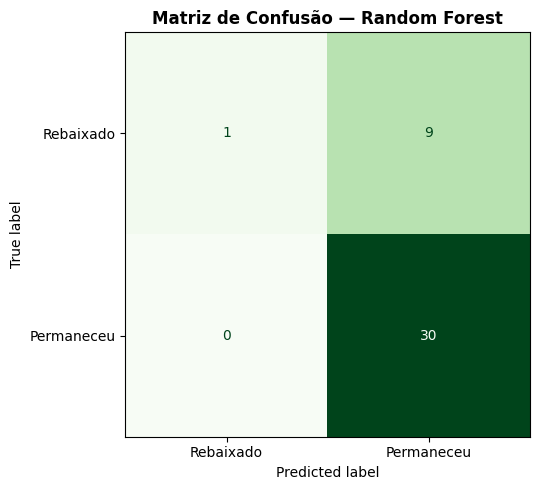

Matriz salva em img/cm_random_forest.png


In [3]:
y_pred = rf.predict(X_te)

acc = accuracy_score(y_te, y_pred)
print(f'Acurácia no teste: {acc:.4f} ({acc*100:.2f}%)')
print()
print('Relatório de Classificação:')
print(classification_report(y_te, y_pred, target_names=['Rebaixado', 'Permaneceu']))

# Matriz de Confusão
os.makedirs(os.path.join('..', 'img'), exist_ok=True)
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rebaixado', 'Permaneceu'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Matriz de Confusão — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'cm_random_forest.png'), dpi=150)
plt.show()
print('Matriz salva em img/cm_random_forest.png')

## Curva ROC e AUC

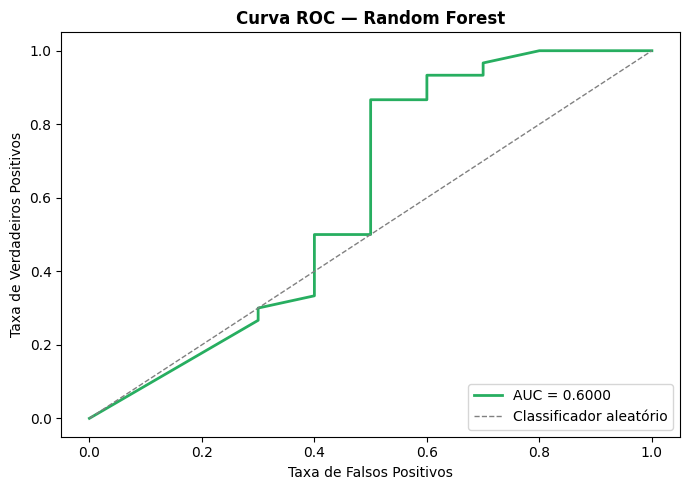

AUC: 0.6000 | Salvo em img/roc_random_forest.png


In [4]:
y_prob = rf.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#27ae60', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificador aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Random Forest', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'roc_random_forest.png'), dpi=150)
plt.show()
print(f'AUC: {roc_auc:.4f} | Salvo em img/roc_random_forest.png')

## Importância das Features

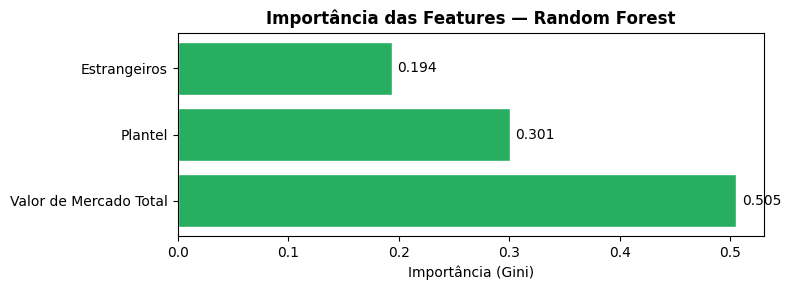

               Feature  Importancia
Valor de Mercado Total       0.5055
               Plantel       0.3008
          Estrangeiros       0.1937


In [5]:
importancias = pd.DataFrame({
    'Feature': FEATURES,
    'Importancia': rf.feature_importances_.round(4)
}).sort_values('Importancia', ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(importancias['Feature'], importancias['Importancia'], color='#27ae60', edgecolor='white')
ax.set_title('Importância das Features — Random Forest', fontweight='bold')
ax.set_xlabel('Importância (Gini)')
for bar, val in zip(ax.patches, importancias['Importancia']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'feat_importance_rf.png'), dpi=150)
plt.show()
print(importancias.to_string(index=False))

## Probabilidades por Clube no Conjunto de Teste

In [6]:
probs = rf.predict_proba(X_te)
idx_reb = list(rf.classes_).index(0)

df_res = df_te[['Clube', 'Temporada']].copy()
df_res['Prob_Rebaixamento(%)'] = (probs[:, idx_reb] * 100).round(2)
df_res['Real']     = y_te
df_res['Previsto'] = rf.predict(X_te)
df_res = df_res.sort_values('Prob_Rebaixamento(%)', ascending=False)

print('Probabilidades de rebaixamento (conjunto de teste):')
df_res

Probabilidades de rebaixamento (conjunto de teste):


,Clube,Temporada,Prob_Rebaixamento(%),Real,Previsto
124,Juventude,2024,57.0,0,0
96,Atlético Goianiense,2024,43.0,0,1
31,Goiás,2023,35.0,1,1
61,Vitória,2024,35.0,0,1
190,Cuiabá,2023,32.0,1,1
110,América Mineiro,2023,30.0,0,1
65,Botafogo,2024,20.0,1,1
193,Cuiabá,2024,18.0,1,1
166,Criciúma,2024,14.0,0,1
77,Flamengo,2023,12.0,1,1


## Salvando o Modelo

In [7]:
os.makedirs(os.path.join('..', 'modelos'), exist_ok=True)
joblib.dump(rf, os.path.join('..', 'modelos', 'random_forest.pkl'))
joblib.dump(scaler, os.path.join('..', 'modelos', 'scaler_rf.pkl'))
print('Modelo salvo em modelos/random_forest.pkl')
print('Scaler salvo em modelos/scaler_rf.pkl')

Modelo salvo em modelos/random_forest.pkl
Scaler salvo em modelos/scaler_rf.pkl


## Comparação com Regressão Logística

Descreva brevemente as diferenças observadas nas métricas e na importância das features.

**Pontos a observar:**
- Compare a acurácia e o AUC entre Random Forest e Regressão Logística.
- Verifique se a ordem de importância das features (Gini) coincide com os coeficientes do modelo linear.
- O Random Forest tende a ter maior robustez a ruído e outliers, mas pode sofrer de overfitting em conjuntos pequenos.
- Com apenas 3 features e ~180 registros de treino, os dois modelos devem apresentar desempenhos próximos.